# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd

/tmp/ipykernel_2363/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

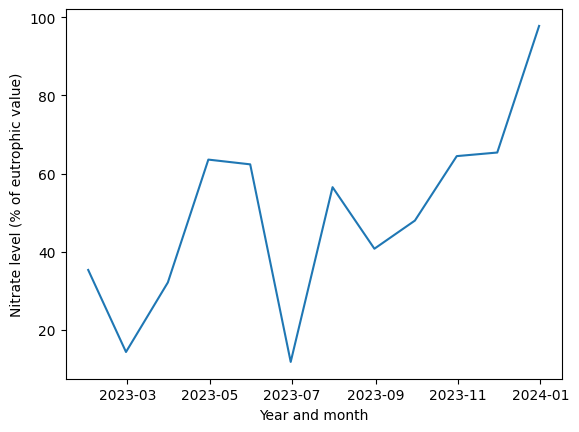

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/tmp/ipykernel_2363/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

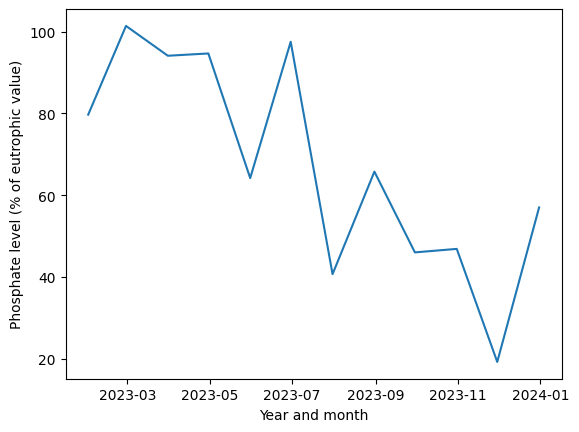

In [4]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

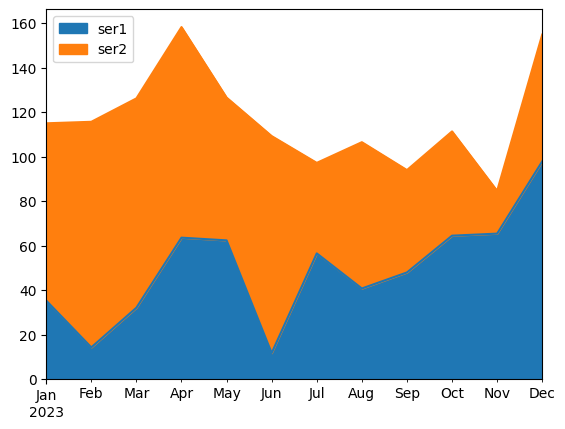

In [5]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

### Comparing Area Plots and Line Graphs

Area plots are visually effective for representing *total nutrient load*, such as nitrate and phosphate combined. 
They highlight cumulative trends and make efficient use of space, especially when comparing proportionate contributions with stacked areas. 
However, they can obscure details—particularly if one variable consistently dominates—making it difficult to discern smaller fluctuations. 
Color overlap, opacity, and annotation become critical for clarity when using this format.

In contrast, separate line plots enhance interpretability by isolating each variable’s trend. 
This clarity benefits analytical tasks, especially when slight variations carry significance (as they often do in water quality analysis). 
But while they offer precision, separate line graphs can fragment the viewer’s perception of overall nutrient dynamics and take up more space. 
Careful axis scaling and consistent color schemes help mitigate these issues when going this route.


# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("Diabetic_Nephropathy.csv")
df.head()

,Sex,Age,Diabetes duration (y),Diabetic retinopathy (DR),Diabetic nephropathy (DN),Smoking,Drinking,Height(cm),Weight(kg),BMI (kg/m2),...,HbA1c (%),FBG (mmol/L),TG（mmoll）,C-peptide (ng/ml）,TC（mmoll）,HDLC（mmoll）,LDLC（mmoll）,Insulin,Metformin,Lipid lowering drugs
0,Male,57,10.0,1,1,1,0,178.0,60.0,18.937003,...,14.1,17.420,1.95,0.98,5.51,1.08,3.71,1,1,1
1,Male,50,8.0,1,1,1,1,172.0,72.5,24.506490,...,10.0,1.024,1.76,0.94,4.40,0.90,2.85,1,0,0
2,Male,53,8.0,1,0,1,0,168.0,62.0,21.967120,...,9.6,8.020,0.84,0.55,4.33,1.04,2.98,1,0,0
3,Male,52,20.0,1,1,0,0,175.0,66.0,21.551020,...,8.1,5.980,1.00,1.36,4.74,1.45,2.90,1,0,0
4,Female,56,12.0,1,1,0,0,159.0,68.8,27.214113,...,10.0,10.770,2.20,3.63,3.37,0.66,1.90,1,0,1


In [8]:
correlation_matrix = df.corr(numeric_only=True)
strong_corrs = correlation_matrix[(correlation_matrix > 0.6) | (correlation_matrix < -0.6)]
print(correlation_matrix)

                                Age  Diabetes duration (y)  \
Age                        1.000000               0.401060   
Diabetes duration (y)      0.401060               1.000000   
Diabetic retinopathy (DR) -0.031814               0.218371   
Diabetic nephropathy (DN)  0.041852               0.174754   
Smoking                   -0.094444              -0.055035   
Drinking                  -0.082860              -0.049529   
Height(cm)                -0.340180              -0.126454   
Weight(kg)                -0.317767              -0.134370   
BMI (kg/m2)               -0.118891              -0.076093   
SBP (mmHg)                 0.132136               0.109141   
DBP (mmHg)                -0.039110              -0.049799   
HbA1c (%)                 -0.038003              -0.145708   
FBG (mmol/L)              -0.104730              -0.081428   
TG（mmoll）                 -0.196963              -0.140939   
C-peptide (ng/ml）         -0.077954              -0.180174   
TC（mmoll

### Weight vs BMI and weight vs height obviously arent viable correlations 

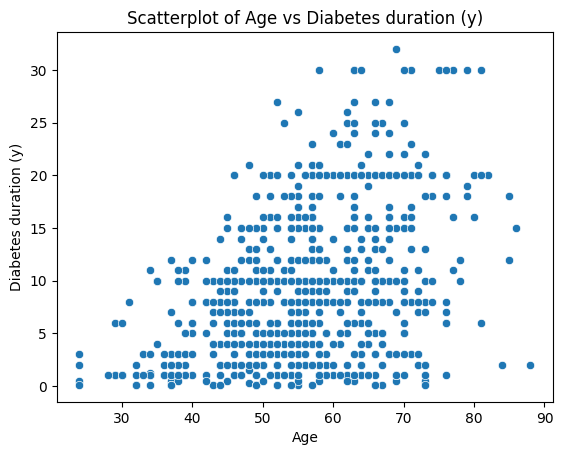

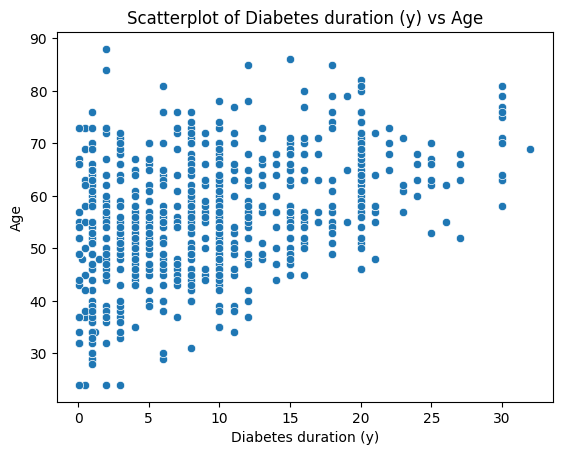

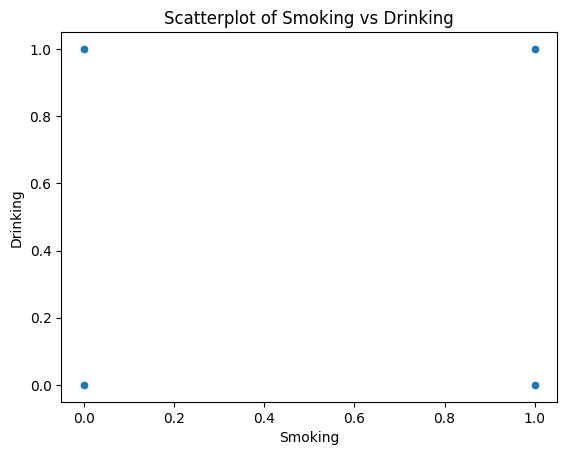

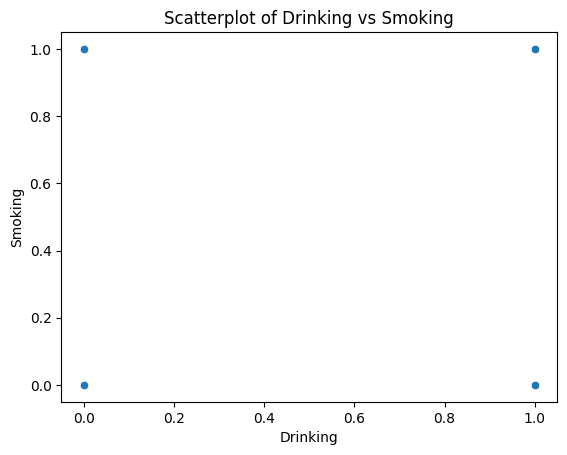

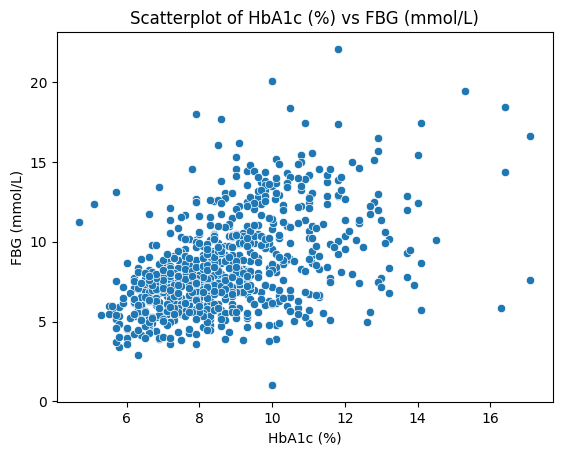

In [9]:
high_threshold = 0.6
low_threshold = 0.4
high_corr_pairs = [
    (col1, col2)
    for col1 in correlation_matrix.columns
    for col2 in correlation_matrix.columns
    if col1 != col2 and abs(correlation_matrix.loc[col1, col2]) < high_threshold and abs(correlation_matrix.loc[col1, col2]) > low_threshold
]

for col1, col2 in high_corr_pairs[:5]:
    sns.scatterplot(data=df, x=col1, y=col2)
    plt.title(f'Scatterplot of {col1} vs {col2}')
    plt.show()


/home/codespace/.local/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


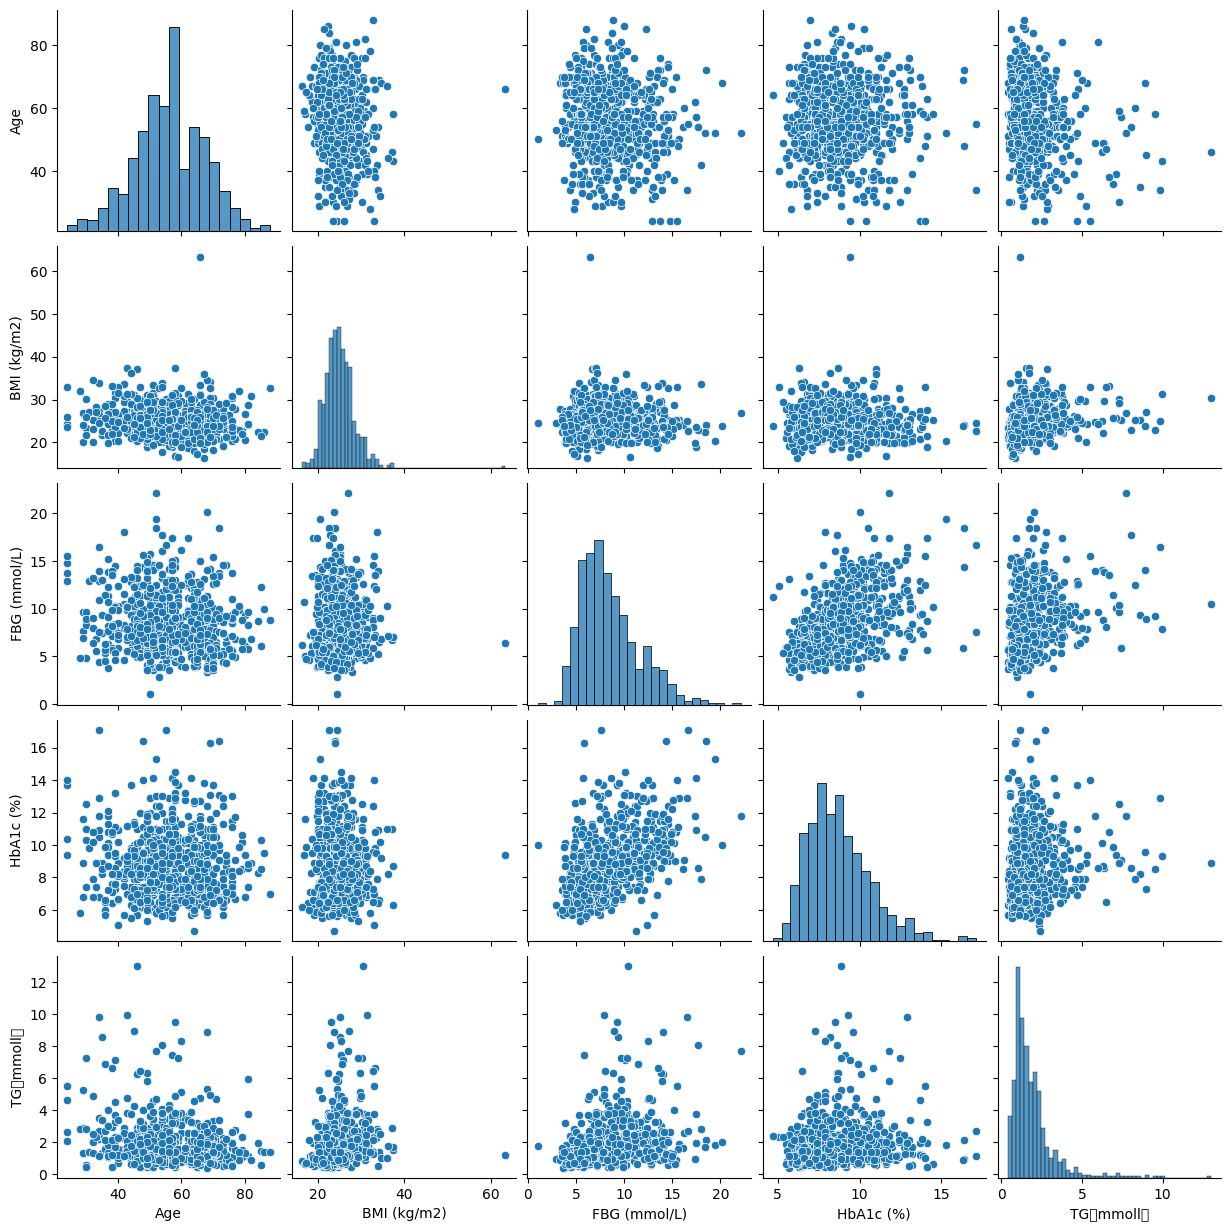

In [10]:
subset = ['Age', 'BMI (kg/m2)', 'FBG (mmol/L)', 'HbA1c (%)', 'TG（mmoll）']
sns.pairplot(df[subset])
plt.show()


## CKD

In [ ]:
df = pd.read_csv("(CKD)-Risk_Factors.csv")
df.head()

,bp (Diastolic),bp limit,sg,al,class,rbc,su,pc,pcc,ba,...,htn,dm,cad,appet,pe,ane,grf,stage,affected,age
2,0,0,1.009 - 1.011,≥ 4,ckd,1,< 0,1,0,1,...,0,0,0,1,0,0,127.281 - 152.446,s1,1,< 12
3,1,1,1.009 - 1.011,3 - 3,ckd,0,< 0,0,0,0,...,0,0,0,0,0,0,127.281 - 152.446,s1,1,< 12
4,0,0,1.015 - 1.017,< 0,ckd,0,< 0,0,0,0,...,0,1,0,1,1,0,127.281 - 152.446,s1,1,12 - 20
5,1,1,≥ 1.023,< 0,notckd,0,< 0,0,0,0,...,0,0,0,0,0,0,102.115 - 127.281,s1,0,12 - 20
6,0,0,1.019 - 1.021,3 - 3,ckd,0,< 0,0,0,0,...,1,1,0,0,0,0,177.612 - 202.778,s1,1,12 - 20


In [30]:
df['class'] = df['class'].replace({'ckd': 1, 'notckd': 0})

df['stage'] = df['stage'].replace({'s1': 1, 's2': 2,'s3': 3, 's4': 4,'s5': 5})

/tmp/ipykernel_2363/3812443779.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['class'] = df['class'].replace({'ckd': 1, 'notckd': 0})
/tmp/ipykernel_2363/3812443779.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['stage'] = df['stage'].replace({'s1': 1, 's2': 2,'s3': 3, 's4': 4,'s5': 5})


In [31]:
df['stage'].unique()

array([1, 4, 3, 2, 5])

In [32]:
df.head()

,bp (Diastolic),bp limit,sg,al,class,rbc,su,pc,pcc,ba,...,htn,dm,cad,appet,pe,ane,grf,stage,affected,age
2,0,0,1.009 - 1.011,≥ 4,1,1,< 0,1,0,1,...,0,0,0,1,0,0,127.281 - 152.446,1,1,< 12
3,1,1,1.009 - 1.011,3 - 3,1,0,< 0,0,0,0,...,0,0,0,0,0,0,127.281 - 152.446,1,1,< 12
4,0,0,1.015 - 1.017,< 0,1,0,< 0,0,0,0,...,0,1,0,1,1,0,127.281 - 152.446,1,1,12 - 20
5,1,1,≥ 1.023,< 0,0,0,< 0,0,0,0,...,0,0,0,0,0,0,102.115 - 127.281,1,0,12 - 20
6,0,0,1.019 - 1.021,3 - 3,1,0,< 0,0,0,0,...,1,1,0,0,0,0,177.612 - 202.778,1,1,12 - 20


In [33]:
def convert_value(val):
    try:
        if isinstance(val, str):
            if '-' in val:
                a, b = map(float, val.split('-'))
                return (a + b) / 2
            if '<' in val:
                return float(val.replace('<', '').strip()) - 1
            if '≥' in val:
                return float(val.replace('≥', '').strip()) + 1
            return float(val)
        return val
    except:
        return np.nan

for col in df.columns:
    df[col] = df[col].apply(convert_value)


In [34]:
df.head()

,bp (Diastolic),bp limit,sg,al,class,rbc,su,pc,pcc,ba,...,htn,dm,cad,appet,pe,ane,grf,stage,affected,age
2,0,0,1.010,5.0,1,1,-1.0,1,0,1,...,0,0,0,1,0,0,139.8635,1,1,11.0
3,1,1,1.010,3.0,1,0,-1.0,0,0,0,...,0,0,0,0,0,0,139.8635,1,1,11.0
4,0,0,1.016,-1.0,1,0,-1.0,0,0,0,...,0,1,0,1,1,0,139.8635,1,1,16.0
5,1,1,2.023,-1.0,0,0,-1.0,0,0,0,...,0,0,0,0,0,0,114.6980,1,0,16.0
6,0,0,1.020,3.0,1,0,-1.0,0,0,0,...,1,1,0,0,0,0,190.1950,1,1,16.0


In [35]:
correlation_matrix = df.corr(numeric_only=True)
strong_corrs = correlation_matrix[(correlation_matrix > 0.6) | (correlation_matrix < -0.6)]
print(correlation_matrix)

                bp (Diastolic)  bp limit        sg        al     class  \
bp (Diastolic)    1.000000e+00  0.866392  0.006607  0.091161  0.111177   
bp limit          8.663922e-01  1.000000 -0.102083  0.186663  0.286264   
sg                6.607172e-03 -0.102083  1.000000 -0.264839 -0.519820   
al                9.116060e-02  0.186663 -0.264839  1.000000  0.578080   
class             1.111772e-01  0.286264 -0.519820  0.578080  1.000000   
rbc               1.943320e-01  0.320456 -0.170669  0.342254  0.287361   
su                8.781076e-02  0.159293 -0.145574  0.360989  0.305883   
pc                8.361246e-02  0.235200 -0.132041  0.594877  0.409960   
pcc              -8.060847e-02  0.044123 -0.179126  0.438927  0.300376   
ba                8.856149e-02  0.208845 -0.109800  0.388157  0.183340   
bgr               1.600434e-03  0.067909 -0.182758  0.368348  0.363729   
bu                1.283835e-01  0.196862 -0.151525  0.368917  0.380444   
sod              -7.128809e-05 -0.1285

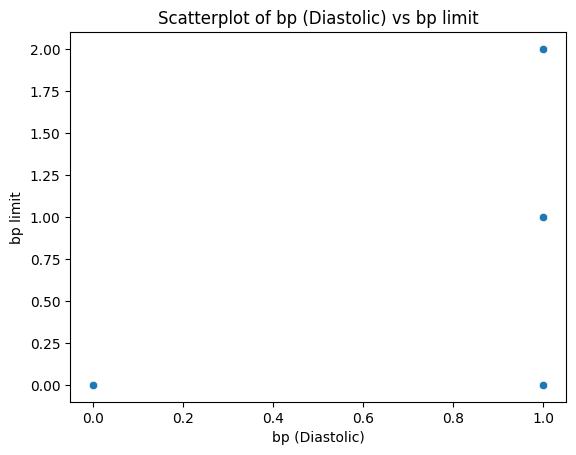

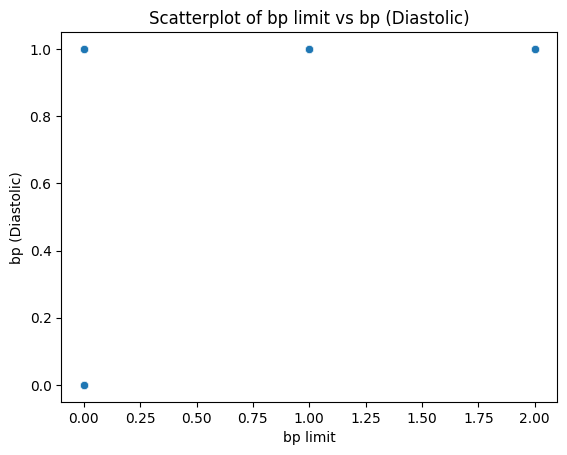

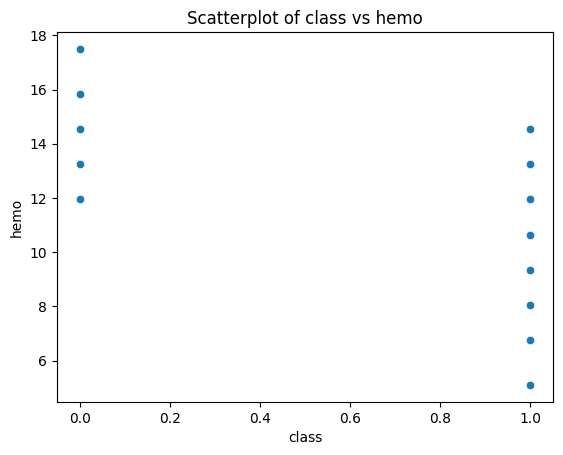

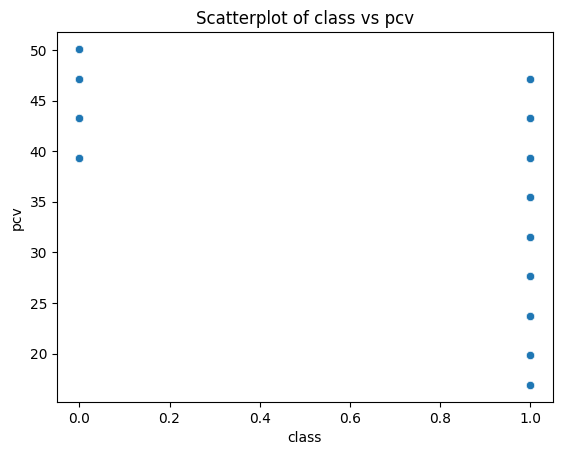

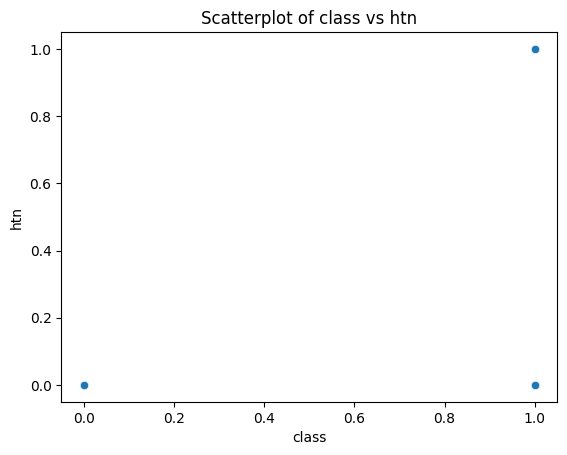

In [36]:
high_threshold = 0.6
low_threshold = 0.4
high_corr_pairs = [
    (col1, col2)
    for col1 in correlation_matrix.columns
    for col2 in correlation_matrix.columns
    if col1 != col2 and abs(correlation_matrix.loc[col1, col2]) > high_threshold
]

for col1, col2 in high_corr_pairs[:5]:
    sns.scatterplot(data=df, x=col1, y=col2)
    plt.title(f'Scatterplot of {col1} vs {col2}')
    plt.show()


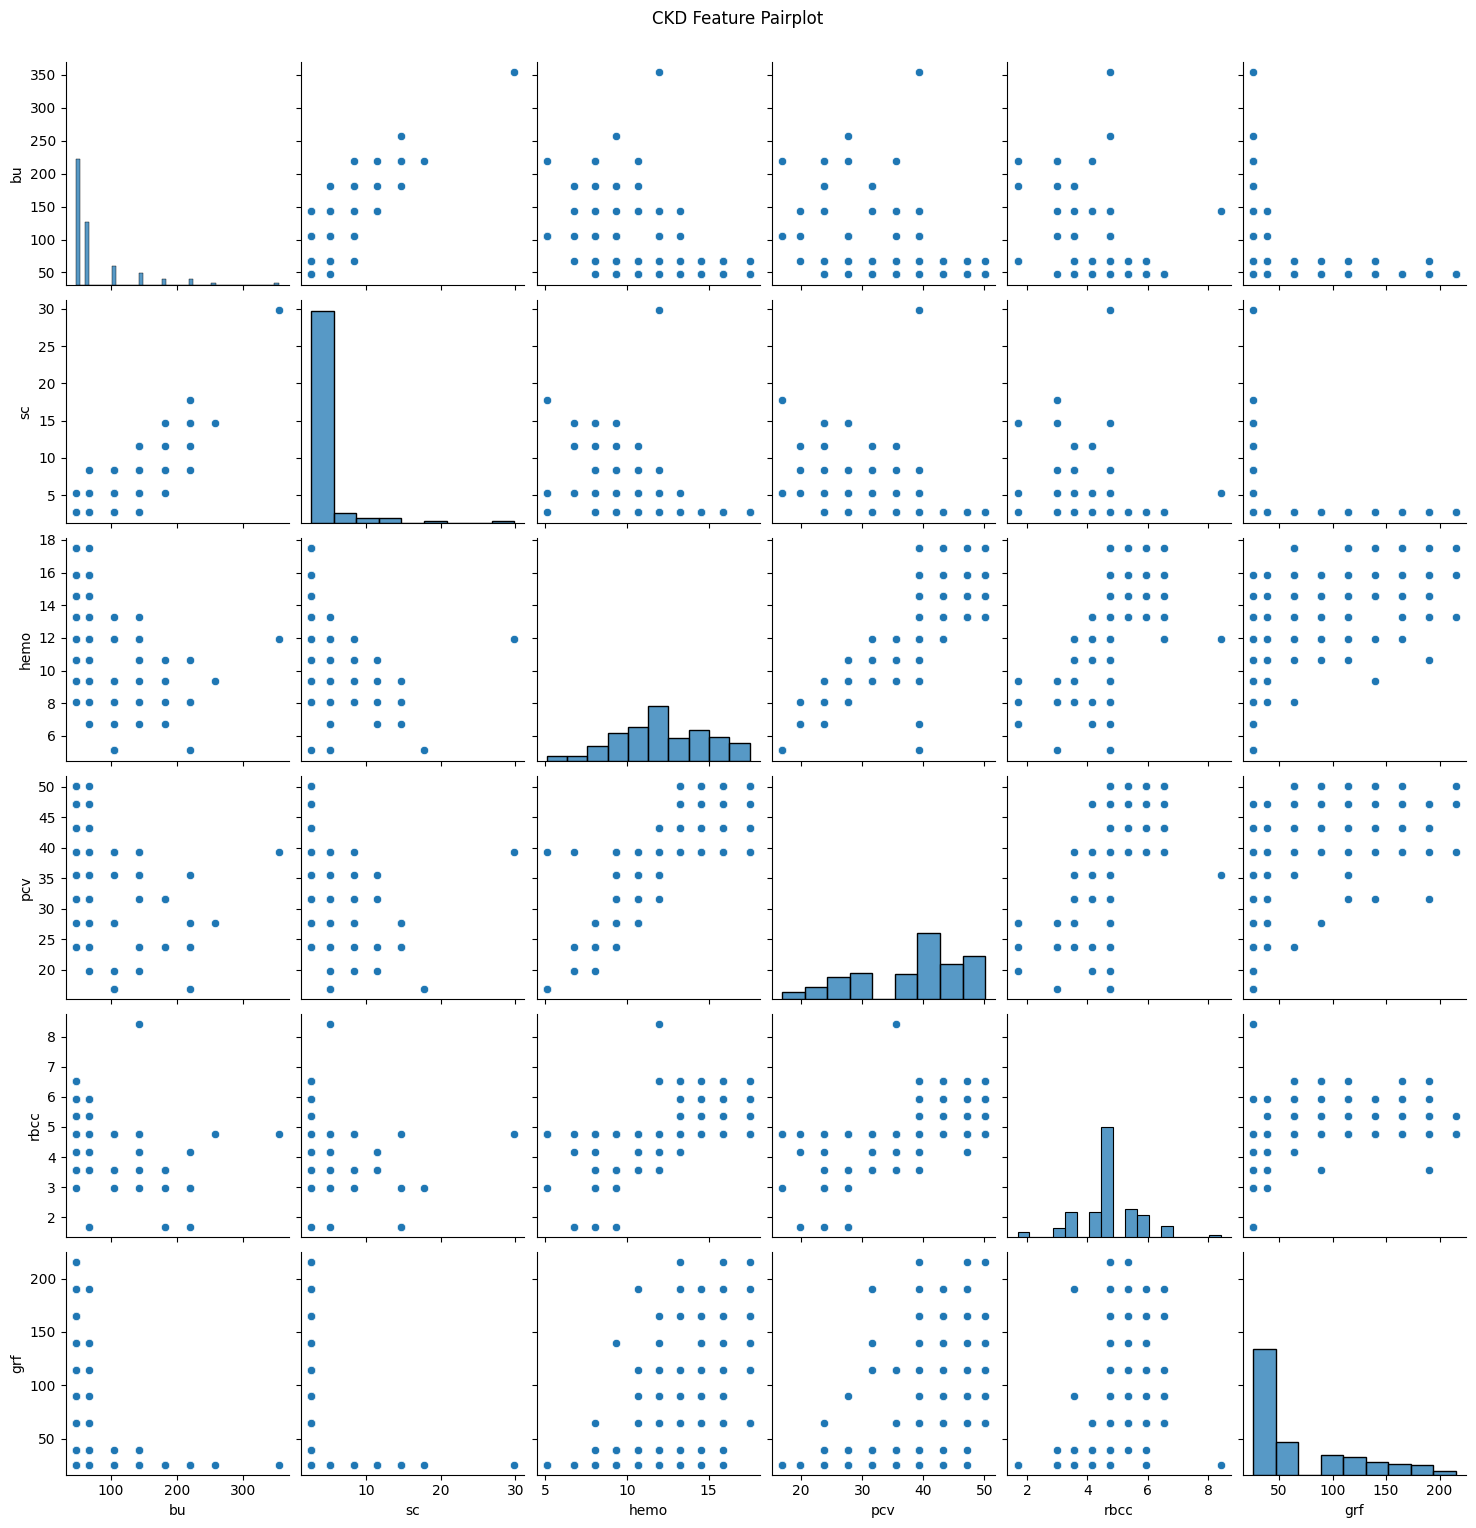

In [37]:
subset = ['bu', 'sc', 'hemo', 'pcv', 'rbcc', 'grf']  # Adjust as needed
sns.pairplot(df[subset].dropna())
plt.suptitle("CKD Feature Pairplot", y=1.02)
plt.show()


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

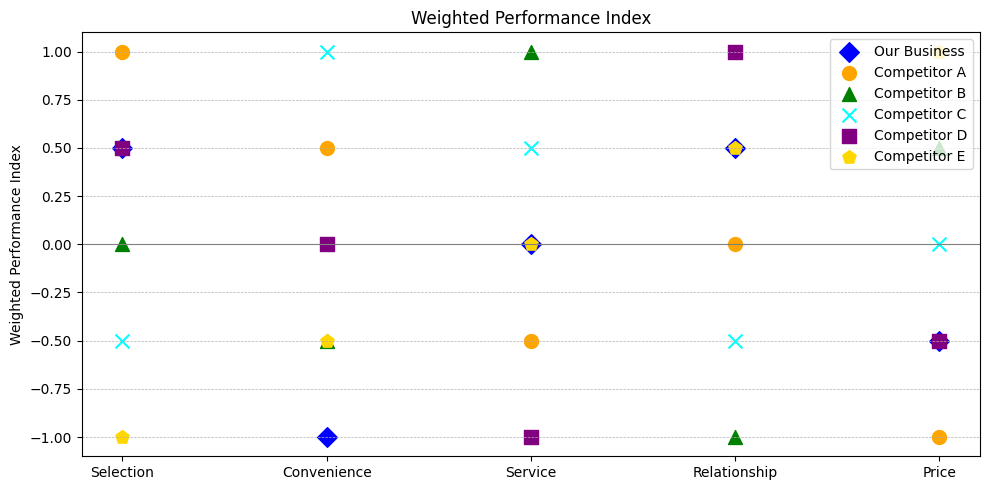

In [2]:
import matplotlib.pyplot as plt

categories = ['Selection', 'Convenience', 'Service', 'Relationship', 'Price']
x = range(len(categories))

data = {
    "Our Business":        [0.5, -1.0, 0.0, 0.5, -0.5],
    "Competitor A":        [1.0, 0.5, -0.5, 0.0, -1.0],
    "Competitor B":        [0.0, -0.5, 1.0, -1.0, 0.5],
    "Competitor C":        [-0.5, 1.0, 0.5, -0.5, 0.0],
    "Competitor D":        [0.5, 0.0, -1.0, 1.0, -0.5],
    "Competitor E":        [-1.0, -0.5, 0.0, 0.5, 1.0]
}

markers = ['D', 'o', '^', 'x', 's', 'p']
colors = ['blue', 'orange', 'green', 'cyan', 'purple', 'gold']

plt.figure(figsize=(10, 5))
for (label, y), marker, color in zip(data.items(), markers, colors):
    plt.scatter(x, y, label=label, marker=marker, color=color, s=100)

plt.axhline(0, color='gray', linewidth=0.8)
plt.xticks(x, categories)
plt.ylabel('Weighted Performance Index')
plt.title('Weighted Performance Index')
plt.legend()
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()
